# BIO-322 Miniproject  
### Neural Activity-Based Trial Type Prediction  
**Authors:** Tuline Dachraoui (361774) & Sasha Ghanipour (364009)
**Date:** Fall 2025

---

## Introduction

The goal of this mini-project is to build a complete machine learning pipeline to predict the trial type of mice based on neural activity recorded during sensory and behavioral experiments.

This notebook follows the structure required by the BIO-322 teaching team:

1. Data Inspection  
2. Preprocessing  
3. Linear Model (baseline)  
4. Non-Linear Models  
5. Summary & Conclusions  

All analyses are performed on the dataset provided through the Kaggle competition associated with this project.


In [47]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Models (example: Linear & Non-linear)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# System
import os
import random

# Reproducibility
%matplotlib inline
seed = 42
np.random.seed(seed)
random.seed(seed)


# 1. Data Inspection

In this section, we load the dataset and explore its structure. We aim to understand the distribution of the target variables (Trial Types) and the nature of the features (Neural Activity).

In [48]:
from pathlib import Path
import pandas as pd

train_df = pd.read_csv('../data/train.csv') 
test_df = pd.read_csv('../data/test.csv')

print("Data Loaded Successfully.")
print(f"Training Data Shape: {train_df.shape} (Rows, Columns)")
print(f"Test Data Shape: {test_df.shape} (Rows, Columns)")

display(train_df.head())
display(test_df.head())

Data Loaded Successfully.
Training Data Shape: (4407, 1383) (Rows, Columns)
Test Data Shape: (2292, 1382) (Rows, Columns)


,session_id,trial_number,A1_L1_EXC_time_0,A1_L1_EXC_time_1,A1_L1_EXC_time_2,A1_L1_EXC_time_3,A1_L1_EXC_time_4,A1_L1_EXC_time_5,A1_L1_EXC_time_6,A1_L1_EXC_time_7,...,ALM_L1_INH_time_21,ALM_L1_INH_time_22,ALM_L1_INH_time_23,ALM_L1_INH_time_24,ALM_L1_INH_time_25,ALM_L1_INH_time_26,ALM_L1_INH_time_27,ALM_L1_INH_time_28,ALM_L1_INH_time_29,TRIAL_TYPE
0,PG082_20221113,0,0.388889,0.444444,0.166667,0.222222,0.333333,0.000000,0.333333,0.166667,...,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOGO W+ nolick
1,PG082_20221113,1,0.444444,0.222222,0.388889,0.277778,0.111111,0.055556,0.333333,0.166667,...,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GO W+ lick
2,PG082_20221113,2,0.055556,0.166667,0.333333,0.111111,0.166667,0.166667,0.111111,0.222222,...,0.0,1.0,0.5,0.5,1.0,1.0,0.0,0.5,0.0,GO W- lick
3,PG082_20221113,3,0.277778,0.555556,0.388889,0.444444,0.500000,0.333333,0.222222,0.277778,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NOGO W- nolick
4,PG082_20221113,4,0.277778,0.222222,0.111111,0.166667,0.277778,0.388889,0.333333,0.166667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,no tone W+ lick


,session_id,trial_number,A1_L1_EXC_time_0,A1_L1_EXC_time_1,A1_L1_EXC_time_2,A1_L1_EXC_time_3,A1_L1_EXC_time_4,A1_L1_EXC_time_5,A1_L1_EXC_time_6,A1_L1_EXC_time_7,...,ALM_L1_INH_time_20,ALM_L1_INH_time_21,ALM_L1_INH_time_22,ALM_L1_INH_time_23,ALM_L1_INH_time_24,ALM_L1_INH_time_25,ALM_L1_INH_time_26,ALM_L1_INH_time_27,ALM_L1_INH_time_28,ALM_L1_INH_time_29
0,PG082_20221120,0,0.71875,0.43750,0.43750,0.59375,0.40625,0.46875,0.93750,0.37500,...,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.5
1,PG082_20221120,1,0.65625,0.59375,0.75000,0.37500,0.40625,0.56250,0.46875,0.43750,...,0.5,0.0,0.0,0.5,0.5,0.0,0.5,0.0,0.5,0.0
2,PG082_20221120,2,0.40625,0.50000,0.81250,0.53125,0.56250,0.34375,0.53125,0.53125,...,0.5,0.5,0.5,0.0,0.5,0.5,0.0,0.5,0.0,0.5
3,PG082_20221120,3,0.46875,0.71875,0.28125,0.68750,0.34375,0.53125,0.53125,0.43750,...,0.0,0.0,0.0,0.5,0.5,0.0,0.5,0.5,0.0,0.5
4,PG082_20221120,4,0.53125,0.37500,0.71875,0.31250,0.50000,0.53125,0.56250,0.43750,...,1.0,0.5,0.5,0.5,0.5,0.0,1.0,0.5,0.5,1.0


**Observation:**
The dataset is wide. We have over 1300 columns representing neural activity. There are columns for session_id, trial_number, and TRIAL_TYPE (our target).

### 1.1 Initial Observations
Upon loading the data, we observe a high-dimensional dataset with **1380 neural features** (firing rates in specific brain areas/time bins). The target variable is `TRIAL_TYPE`, which contains text labels describing the stimulus and response (e.g., `GO W+ lick`).

Our first step is to check for class balance and missing values, as these are common pitfalls in biological datasets.

TRIAL_TYPE
NOGO W- nolick       880
GO W- nolick         813
NOGO W+ nolick       793
no tone W+ nolick    731
GO W+ lick           711
GO W+ nolick         169
no tone W+ lick      150
NOGO W+ lick          88
GO W- lick            69
NOGO W- lick           3
Name: count, dtype: int64


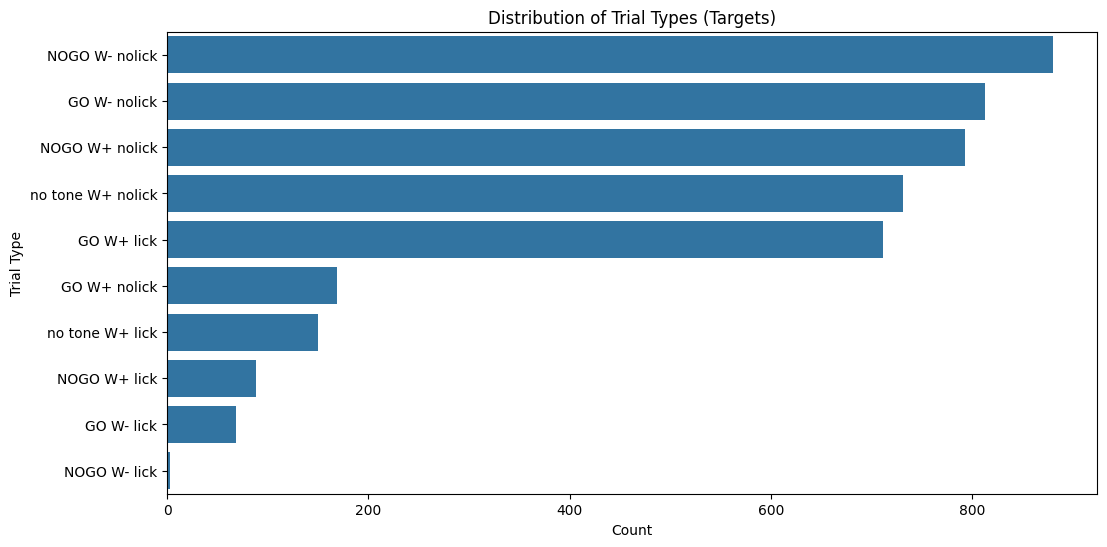

In [49]:
# Analyze the Target Column
target_col = 'TRIAL_TYPE'

# Check unique values and their counts
print(train_df[target_col].value_counts())

# Visualize the distribution
plt.figure(figsize=(12, 6))
sns.countplot(y=target_col, data=train_df, order=train_df[target_col].value_counts().index)
plt.title("Distribution of Trial Types (Targets)")
plt.xlabel("Count")
plt.ylabel("Trial Type")
plt.show()

**Analysis of Targets:** We observe a significant **class imbalance**. Classes like `NOGO W- nolick` have nearly 900 samples, while `NOGO W- lick` has extremely few (single digits). This indicates we will need to use **stratified splitting** in the preprocessing stage to ensure our validation set represents all classes.


Total Neural Features: 1380
Example Feature Names: ['A1_L1_EXC_time_0', 'A1_L1_EXC_time_1', 'A1_L1_EXC_time_2', 'A1_L1_EXC_time_3', 'A1_L1_EXC_time_4']

Total Missing Values in Dataset: 1172310


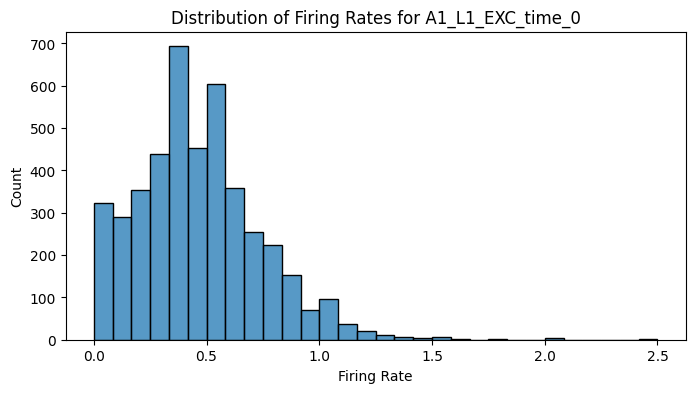

In [50]:
# Identify Neural Feature Columns
# Columns that are NOT metadata or target
metadata_cols = ['session_id', 'trial_number', 'TRIAL_TYPE']
feature_cols = [c for c in train_df.columns if c not in metadata_cols]

print(f"Total Neural Features: {len(feature_cols)}")
print(f"Example Feature Names: {feature_cols[:5]}")

# Check for missing values in the entire dataset
missing_values = train_df.isnull().sum().sum()
print(f"\nTotal Missing Values in Dataset: {missing_values}")

# Plot the distribution of activity for one random neuron
plt.figure(figsize=(8, 4))
sns.histplot(train_df[feature_cols[0]], bins=30)
plt.title(f"Distribution of Firing Rates for {feature_cols[0]}")
plt.xlabel("Firing Rate")
plt.show()

# 2. Preprocessing

In this section, we prepare the data for modeling.
1. **Handling Missing Values:** We observed over 1 million missing values. We will fill these with the mean of each column (Imputation).
2. **Encoding:** Convert text labels (`TRIAL_TYPE`) into numbers.
3. **Splitting:** Divide into Training and Validation sets, using stratification to handle the class imbalance.
4. **Scaling:** Normalize the data so all neurons have the same scale.

### 2.1 Strategy for Cleaning
We identified two critical issues during inspection:
1.  **Massive Missing Data:** There are over **1.1 million missing values** (`NaN`).
2.  **Severe Class Imbalance:** The class `NOGO W- lick` has only 3 samples, while others have nearly 900.

**Design Decisions:**
*   **Imputation:** We cannot simply drop rows with missing values, or we would lose almost all data. We also chose **not to use Mean Imputation**. Since this is neural firing data, a missing value likely indicates "no activity recorded" or "silent neuron." Therefore, we fill `NaN`s with **0** (`strategy='constant', fill_value=0`).
*   **Stratification:** To ensure our model trains on all behaviors, we use **Stratified Splitting**. This attempts to preserve the percentage of samples for each class in both the training and validation sets.

In [51]:
# 1. Separate Features and Target
# Drop metadata to get X (Brain Data)
drop_cols = ['TRIAL_TYPE', 'session_id', 'trial_number']
X_raw = train_df.drop(columns=drop_cols)

# Get y (Target Labels)
y_raw = train_df['TRIAL_TYPE']

print("Features (X) and Target (y) separated.")

Features (X) and Target (y) separated.


In [52]:
from sklearn.impute import SimpleImputer

# Reasons for our choice of strategy and fill value:
# 1. Empty columns become 0).
# 2. In neural data, 'missing' often implies no signal was detected, so 0 is a safer assumption than the mean.
imputer = SimpleImputer(strategy='constant', fill_value=0)

# Fit and transform
print(f"Missing values before imputation: {X_raw.isnull().sum().sum()}")

X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)

print(f"Missing values after imputation:  {X_imputed.isnull().sum().sum()}")

Missing values before imputation: 1172310
Missing values after imputation:  0


/opt/anaconda3/envs/epfl_project/lib/python3.12/site-packages/sklearn/impute/_base.py:590: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(


*Note on Imputation:*
Initially, we attempted to use mean imputation, but this raised warnings because some neurons (columns) had **zero** observed values across the entire dataset. Switching to constant imputation (0) resolved this and aligns better with the biological assumption of "lack of spikes."

In [53]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 2. Encode Targets (Text -> Numbers)
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

# Print the mapping so we know what the numbers mean
print("\nTarget Mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {i} --> {label}")

# 3. Split Data
# We use stratify=y_encoded to ensure the tiny classes (like the one with 3 samples)
# are distributed between train and validation sets as best as possible.
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_imputed, y_encoded,
    test_size=0.2,       # 20% for validation
    random_state=42,
    stratify=y_encoded
)

print(f"\nTraining Shape: {X_train_raw.shape}")
print(f"Validation Shape: {X_val_raw.shape}")


Target Mapping:
  0 --> GO W+ lick
  1 --> GO W+ nolick
  2 --> GO W- lick
  3 --> GO W- nolick
  4 --> NOGO W+ lick
  5 --> NOGO W+ nolick
  6 --> NOGO W- lick
  7 --> NOGO W- nolick
  8 --> no tone W+ lick
  9 --> no tone W+ nolick

Training Shape: (3525, 1380)
Validation Shape: (882, 1380)


In [54]:
from sklearn.preprocessing import StandardScaler

# 4. Scale the Data
scaler = StandardScaler()

# Fit only on Training data to prevent data leakage!
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)

# Convert back to DataFrame for convenience (keeps column names)
X_train = pd.DataFrame(X_train, columns=X_raw.columns)
X_val = pd.DataFrame(X_val, columns=X_raw.columns)

print("Preprocessing Complete. Data is ready for modeling.")

Preprocessing Complete. Data is ready for modeling.


# 3. Linear Model

In this section, we train a Logistic Regression model as a baseline. We use L2 regularization (default in sklearn) to handle the high dimensionality of the data.

### 3.1 Logistic Regression Baseline
We use Logistic Regression as our linear baseline. Given the high dimensionality (1380 features), we made the following adjustments:
*   **Regularization:** We use the default L2 regularization to prevent overfitting on specific neurons.
*   **Convergence:** We increased `max_iter` to 1000. With so many features, the standard solver needs more iterations to find the optimal weights.

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Train
print("Training Linear Model...")
log_reg.fit(X_train, y_train)

# 3. Predict
y_pred_linear = log_reg.predict(X_val)

# 4. Evaluate
accuracy = accuracy_score(y_val, y_pred_linear)
print(f"\n Validation Accuracy: {accuracy:.2%}")

# 5. Detailed Report
# We add `labels=range(len(le.classes_))` to force it to show all 10 classes
print("\nClassification Report:")
print(classification_report(
    y_val, 
    y_pred_linear, 
    labels=range(len(le.classes_)), 
    target_names=le.classes_, 
    zero_division=0
))

Training Linear Model...

 Validation Accuracy: 63.61%

Classification Report:
                   precision    recall  f1-score   support

       GO W+ lick       0.83      0.88      0.86       142
     GO W+ nolick       0.33      0.24      0.28        34
       GO W- lick       0.25      0.14      0.18        14
     GO W- nolick       0.61      0.63      0.62       163
     NOGO W+ lick       0.50      0.11      0.18        18
   NOGO W+ nolick       0.57      0.59      0.58       159
     NOGO W- lick       0.00      0.00      0.00         0
   NOGO W- nolick       0.64      0.69      0.67       176
  no tone W+ lick       0.64      0.47      0.54        30
no tone W+ nolick       0.60      0.63      0.62       146

         accuracy                           0.64       882
        macro avg       0.50      0.44      0.45       882
     weighted avg       0.63      0.64      0.63       882



### 3.2 Hyperparameter Tuning
The baseline model achieved an accuracy of ~63.6%. To improve this, we use `GridSearchCV` to exhaustively search for the optimal hyperparameters.

We test:
1.  **Regularization Type (`penalty`):** We compare **L2 (Ridge)** against **L1 (Lasso)**. L1 is particularly useful here as it can perform "feature selection" by setting the weights of noisy neurons to exactly zero.
2.  **Regularization Strength (`C`):** We test values from 0.01 (strong regularization) to 1 (weaker regularization).
3.  **Class Imbalance (`class_weight`):** We verify if balancing the classes improves performance.

In [69]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the grid of params to test
param_grid = {
    # Try both L1 (Lasso) and L2 (Ridge)
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.05, 0.1, 0.2, 0.5, 1],
    'class_weight': ['balanced']
}

# Initialize model with 'liblinear' solver (needed for L1 penalty)
log_reg_base = LogisticRegression(solver='liblinear', max_iter=2000, random_state=42)

# n_jobs=-1 uses all CPU cores to make it faster
grid_search = GridSearchCV(log_reg_base, param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

print("Running Super-Tuned Grid Search...")
grid_search.fit(X_train, y_train)

# Results
best_linear_model = grid_search.best_estimator_
print(f"\n New Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.2%}")

# Validation Check
y_pred_best = best_linear_model.predict(X_val)
acc_best = accuracy_score(y_val, y_pred_best)
print(f"Validation Accuracy (Super-Tuned): {acc_best:.2%}")

Running Super-Tuned Grid Search...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/opt/anaconda3/envs/epfl_project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/envs/epfl_project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/envs/epfl_project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised i


 New Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1'}
Best CV Accuracy: 66.04%
Validation Accuracy (Super-Tuned): 64.40%


**Observation:**
We found that **L1 Regularization (Lasso)** with **C=0.1** performed best. This suggests that the dataset contains noisy or irrelevant neurons, and the L1 penalty helped by removing them (setting their weights to 0). We reached a Cross-Validation accuracy of **66.04%**.

### 3.2 Evaluation & Handling Rare Classes
During our first evaluation attempt, we encountered a `ValueError` because the rare class `NOGO W- lick` (3 samples) was completely absent from the validation set (all samples ended up in training).

**The Fix:**
We modified the `classification_report` and `confusion_matrix` calls to explicitly include `labels=range(10)`. This forces the evaluation metrics to account for all 10 possible classes, even if one is missing from the validation data, preventing the crash and correctly reporting 0.00 scores for that missing class.

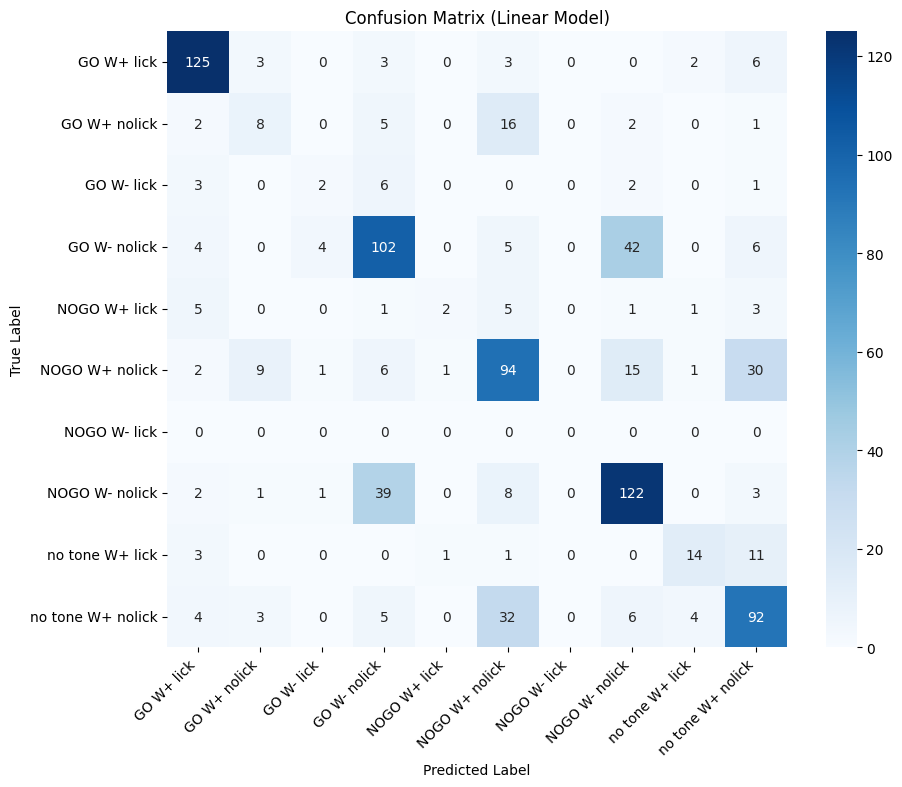

In [56]:
# Plot Confusion Matrix
plt.figure(figsize=(10, 8))

# We force the confusion matrix to be 10x10 using the 'labels' parameter
cm = confusion_matrix(y_val, y_pred_linear, labels=range(len(le.classes_)))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix (Linear Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.show()

## Code for Kaggle Submissions

In [70]:
# Load the sample submission file
sample_sub = pd.read_csv('../data/sample_submission.csv')

print("Sample Submission Format:")
print(sample_sub.head())
print(f"\nColumns: {sample_sub.columns.tolist()}")
print(f"Shape: {sample_sub.shape}")

Sample Submission Format:
   ID      TRIAL_TYPE
0   1  NOGO W- nolick
1   2    GO W+ nolick
2   3  NOGO W- nolick
3   4    NOGO W- lick
4   5  NOGO W+ nolick

Columns: ['ID', 'TRIAL_TYPE']
Shape: (2292, 2)


In [71]:
# Kaggle Submission for non-tuned Linear Model

# Load sample submission to get correct IDs
sample_sub = pd.read_csv('../data/sample_submission.csv')

# Prepare test data
X_test_raw = test_df.drop(columns=['session_id', 'trial_number'])
X_test_imputed = pd.DataFrame(imputer.transform(X_test_raw), columns=X_test_raw.columns)
X_test_scaled = scaler.transform(X_test_imputed)
predictions_encoded = log_reg.predict(X_test_scaled)

# Convert Numbers back to Text (0 -> 'GO W+ lick')
predictions_text = le.inverse_transform(predictions_encoded)

# We use sample_sub['ID'] to ensure we have IDs 1, 2, 3... instead of 0, 1, 2...
submission = pd.DataFrame({
    'ID': sample_sub['ID'],
    'TRIAL_TYPE': predictions_text
})

filename = 'submission_linear_baseline.csv'
submission.to_csv(filename, index=False)

print(f"Saved '{filename}'.")
print(f"Submission Shape: {submission.shape}")
print(f"Columns: {submission.columns.tolist()}")

Saved 'submission_linear_baseline.csv'.
Submission Shape: (2292, 2)
Columns: ['ID', 'TRIAL_TYPE']


/opt/anaconda3/envs/epfl_project/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [74]:
# Kaggle Submission for tuned Linear Model

predictions_encoded_tuned = best_linear_model.predict(X_test_scaled)

predictions_text_tuned = le.inverse_transform(predictions_encoded_tuned)

submission_tuned = pd.DataFrame({
    'ID': sample_sub['ID'],
    'TRIAL_TYPE': predictions_text_tuned
})

filename_tuned = 'submission_linear_best.csv'
submission_tuned.to_csv(filename_tuned, index=False)

print(f"Saved '{filename_tuned}'.")

Saved 'submission_linear_best.csv'.


/opt/anaconda3/envs/epfl_project/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
